LOGISTIC REGRESSION

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
dataset=pd.read_csv('')
print(dataset)
#Slice the dataset as descriptive and target variable
x=dataset.iloc[:,0:7].values  # Select all numerical features (N, P, K, temperature, humidity, ph, rainfall)
y=dataset.iloc[:,7].values   # Select the 'label' column as the target variable
print(y)
print(np.shape(x))
print(dataset.head())
#Splitting the dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
print(x_train[0:10])
#Standardization
from sklearn.preprocessing import StandardScaler
stdsc=StandardScaler()
x_train_std=stdsc.fit_transform(x_train)
x_test_std=stdsc.transform(x_test)
print(x_train_std[0:10])
#create an object of the algorithm/model
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression(random_state=0)
#train the model
clf.fit(x_train_std,y_train)
#predict the model on testing dataset
y_pred=clf.predict(x_test_std)
from sklearn.metrics import accuracy_score
print("Accuracy: ",accuracy_score(y_test,y_pred))
#Evaluation metrics
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)
from sklearn.metrics import classification_report
print("report",classification_report(y_test,y_pred))
# Visualising the Training set results
from matplotlib.colors import ListedColormap



      N   P   K  temperature   humidity        ph    rainfall   label
0    90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1    85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2    60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3    74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4    78  42  42    20.130175  81.604873  7.628473  262.717340    rice
..   ..  ..  ..          ...        ...       ...         ...     ...
394  24  61  17    22.637142  65.445449  6.233269   38.304111  lentil
395   2  79  15    21.535779  65.472277  7.505284   35.751076  lentil
396  26  63  17    29.878546  65.730852  6.950301   44.956548  lentil
397  27  61  15    25.265329  67.100046  6.958055   48.339412  lentil
398  24  70  16    25.178853  68.933073  6.548035   35.034848  lentil

[399 rows x 8 columns]
['rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice'
 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' 'rice' '

### Feature Importance Visualization

Let's visualize the importance of each feature in the Logistic Regression model using a bar plot of their coefficients. We will consider the absolute mean of coefficients across all classes for each feature as its importance.

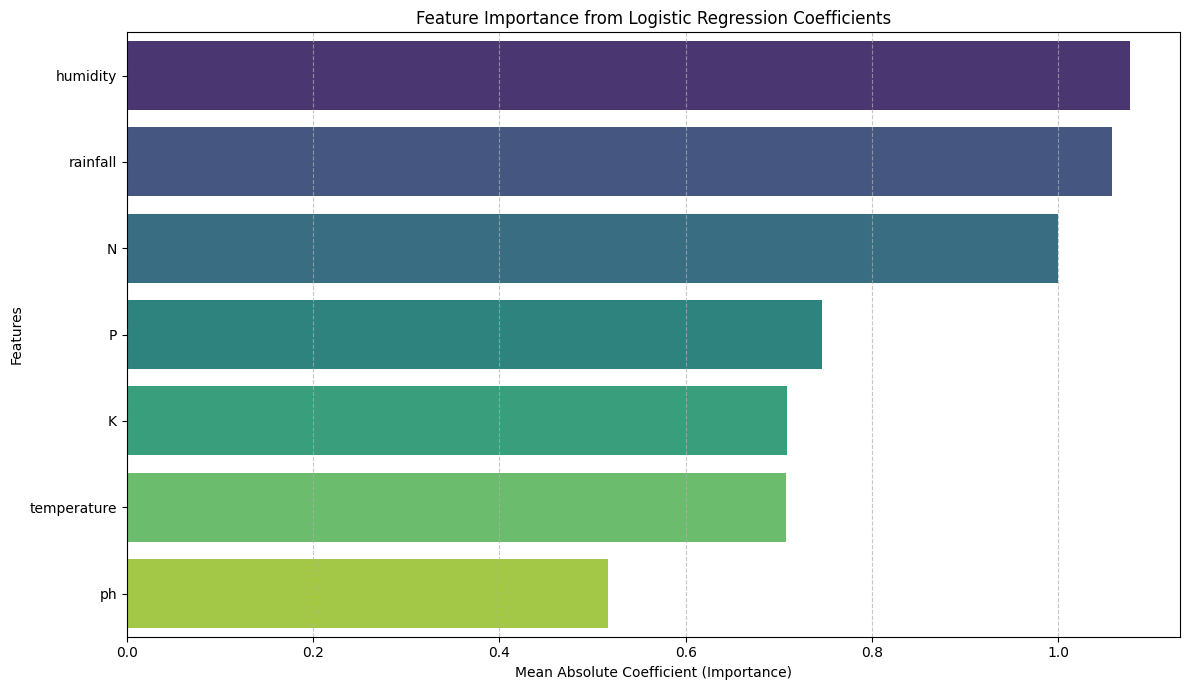

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the original dataset
feature_names = dataset.columns[0:7].tolist()

# Get the coefficients from the trained Logistic Regression model
# clf.coef_ is a 2D array (n_classes, n_features)
coefficients = clf.coef_

# Calculate the mean absolute coefficient for each feature across all classes
# This gives a single 'importance' score for each feature
feature_importance = np.mean(np.abs(coefficients), axis=0)

# Create a pandas Series for easier handling and sorting
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance from Logistic Regression Coefficients')
plt.xlabel('Mean Absolute Coefficient (Importance)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

DECISION TREE CLASSIFIER

In [ ]:
#Create decision tree classifier object
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy",max_depth=None,min_samples_split=5,min_samples_leaf=5)
#Train model : fit method
model.fit(x_train,y_train)
print(model)
#Predicting the testing model
y_pred=model.predict(x_test)
print(y_pred)
from sklearn.metrics import confusion_matrix
c = confusion_matrix(y_test,y_pred)
print(c)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))
#Visualisation
from sklearn import tree
# Update feature names to match the dataset
fn=dataset.columns[0:7].tolist() # Corrected feature names
cn=np.unique(y).tolist() # Corrected class names dynamically
fig, axes=plt.subplots(nrows=1,ncols=1,figsize=(40,30),dpi=300)
tree.plot_tree(model,feature_names=fn,class_names=cn,filled=True);

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=5,
                       min_samples_split=5)
['chickpea' 'blackgram' 'blackgram' 'kidneybeans' 'pigeonpeas' 'maize'
 'kidneybeans' 'mungbean' 'chickpea' 'pigeonpeas' 'rice' 'chickpea'
 'chickpea' 'blackgram' 'rice' 'maize' 'mungbean' 'chickpea' 'pigeonpeas'
 'pigeonpeas' 'kidneybeans' 'mungbean' 'chickpea' 'blackgram'
 'kidneybeans' 'blackgram' 'maize' 'rice' 'mungbean' 'chickpea'
 'kidneybeans' 'blackgram' 'lentil' 'pigeonpeas' 'maize' 'maize' 'maize'
 'kidneybeans' 'kidneybeans' 'lentil' 'chickpea' 'blackgram' 'rice' 'rice'
 'mungbean' 'maize' 'blackgram' 'mungbean' 'kidneybeans' 'pigeonpeas'
 'pigeonpeas' 'chickpea' 'mungbean' 'kidneybeans' 'mungbean' 'blackgram'
 'maize' 'rice' 'rice' 'rice' 'maize' 'mungbean' 'rice' 'lentil'
 'kidneybeans' 'lentil' 'chickpea' 'rice' 'kidneybeans' 'blackgram' 'rice'
 'mungbean' 'maize' 'rice' 'chickpea' 'rice' 'lentil' 'blackgram' 'lentil'
 'blackgram' 'blackgram' 'pigeonpeas' 'maize' '

RANDOM TREE CLASSIFIER

In [ ]:
#Fitting the classifier into the training set
from sklearn.ensemble import RandomForestClassifier
RFmodel=RandomForestClassifier(n_estimators=200,criterion="entropy",random_state=0)
RFmodel.fit(x_train,y_train)

#Predict the test set results
y_pred_rf=RFmodel.predict(x_test)
print(y_pred_rf)

#Making the confusion matrix
from sklearn.metrics import confusion_matrix
cmrf=confusion_matrix(y_test,y_pred_rf)
print(cmrf)

from sklearn.metrics import accuracy_score
print("Random Forest",accuracy_score(y_test,y_pred_rf))


['chickpea' 'blackgram' 'blackgram' 'kidneybeans' 'pigeonpeas' 'maize'
 'kidneybeans' 'mungbean' 'chickpea' 'pigeonpeas' 'rice' 'chickpea'
 'chickpea' 'blackgram' 'rice' 'maize' 'mungbean' 'chickpea' 'pigeonpeas'
 'pigeonpeas' 'kidneybeans' 'mungbean' 'chickpea' 'blackgram'
 'kidneybeans' 'blackgram' 'maize' 'rice' 'mungbean' 'chickpea'
 'kidneybeans' 'blackgram' 'lentil' 'pigeonpeas' 'maize' 'maize' 'maize'
 'kidneybeans' 'kidneybeans' 'lentil' 'chickpea' 'blackgram' 'rice' 'rice'
 'mungbean' 'maize' 'blackgram' 'mungbean' 'kidneybeans' 'pigeonpeas'
 'pigeonpeas' 'chickpea' 'mungbean' 'kidneybeans' 'mungbean' 'blackgram'
 'maize' 'rice' 'rice' 'rice' 'maize' 'mungbean' 'rice' 'lentil'
 'kidneybeans' 'lentil' 'chickpea' 'rice' 'kidneybeans' 'blackgram' 'rice'
 'mungbean' 'maize' 'rice' 'chickpea' 'rice' 'lentil' 'blackgram' 'lentil'
 'blackgram' 'blackgram' 'maize' 'maize' 'chickpea' 'blackgram'
 'pigeonpeas' 'chickpea' 'lentil' 'lentil' 'blackgram' 'lentil' 'mungbean'
 'maize' 'rice' 

NAIVE-BAYES CLASSIFIER

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)
y_pred_nb = nb.predict(x_test)
cmnb = confusion_matrix(y_test, y_pred_nb)
print(cmnb)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)


[[20  0  0  0  0  0  0  0]
 [ 0 16  0  0  0  0  0  0]
 [ 0  0 16  0  0  0  0  0]
 [ 0  0  0 14  0  0  0  0]
 [ 0  0  0  0 20  0  0  0]
 [ 0  0  0  0  0 18  0  0]
 [ 0  0  0  0  0  0 13  0]
 [ 0  0  0  0  0  0  0 16]]
Accuracy: 1.0
